# Exploración inicial de los datos en crudo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import os

In [14]:
#Fases = pd.read_parquet("res//raw/CPRMOTask.parquet")
#OF = pd.read_parquet("res//raw/CPRManufacturingOrder.parquet")
#Imputations = pd.read_parquet("res//raw/imputaciones.parquet")
pd.set_option("display.max_columns", None)  
pd.set_option("display.width", None)        

# Imputaciones MES
ruta_imputations = os.path.join("res\\raw", "imputaciones.csv")
columns_imputations = ["FechaCreacionDte",	"smNodoId",	"smNodoNme",	"smOrdenId",	"smMaterialId",	"smOrdenNme",	"smFaseId",	"smFaseNme",	"CantidadManualOKNbr",	"CantidadManualNOKNbr",	"MinutosRealNbr",	"MinutosPreparacionNbr",	"MinutosProduccionNbr",	"PorcentajeDedicacionNbr",	"ProductivoInd",	"smIncidenciaId",	"smIncidenciaNme",	"smFasePersonalizado1Txt",	"smNodoId2",	"smNodoPersonalizado1Nbr",	"smNodoPersonalizado2Nbr",	"ssEnumFaseEstadoId",	"SmFaseUid",	"TraspasadoInd",	"JsonBodyTxt",	"JsonResponseTxt"]
imputations = pd.read_csv(ruta_imputations, sep=";", header=None, names=columns_imputations)

# Fase ERP
ruta_FASE = os.path.join("res\\raw", "CPRMOTask.csv")
columns_FASE = ["IDMOTask", "CodCompany", "IDManufacturingOrder", "CodMOTask", "Description", "Notes", "Order", "PreparationTime", "ExecutionTime", "RepetitionTime", "TimeUnit", "ProductEntry", "MaterialExit", "DelimitationType", "DelimitationDate", "AllowFraccionate", "MinimumFraction", "IDUsualTask", "TaskType", "IDMOTaskParent", "RepetitionLot", "External", "IDArticleExternal", "Quantity", "IDSupplier", "IDTaskType", "RepetitionTimeReal", "PlannedStartDate", "PlannedEndDate", "Group", "IDTask", "PercentProgress", "SeriesRequired", "QualityStatus", "InspectedDate", "Priority", "OptimizationFeature", "Fixed", "WithoutTimetable", "OccupancyType", "OccupancyHours", "OccupancyPercent", "ManualEndDate", "ManualStartDate", "Blocked", "DelimitationObligatory", "IDBudgetCategory", "ResourcePlanType", "SplitNumber", "ManualPlanning", "IDBudgetEmployee", "IDBudgetMachine", "IDBudgetTool", "IDBudgetMaterial", "IDBudgetOtherCost", "RowTimestamp", "WorkUnits", "LastModifiedBy", "IDProductFormula", "DateReplanify", "LotsOrder", "PrintLabels", "AutoExecutionImputation", "IDSiteMaterial", "IDWarehouseMaterial", "GroupingNumber", "CreationTimestamp", "RowCreatedBy", "BlockedMaterial", "BlockedCost", "ImputationCostUpdated", "Canceled", "RealEndDate", "IDCheckList", "NotOverlapCode", "TiedCode", "GroupedManufacturing", "ReleaseKeptResources", "DelayMargin", "BlockedChangeMaterial", "IDHourType", "Color", "SetToQtyConversionFactor", "AdjustTaskToDay", "PercentProgressType", "StatusTaskMES"]
FASE = pd.read_csv(ruta_FASE, sep=";", header=None, names=columns_FASE)

# OF ERP
ruta_OF = os.path.join("res\\raw", "CPRManufacturingOrder.csv")
columns_OF = ["IDManufacturingOrder", "CodCompany",	"CodManufacturingOrder", "IDArticle", "IDStructure", "Description", "TimeUnitDefault",	"IDStructureType",	"Notes", "Quantity", "IDWareHouse", "PlannedEndDate", "PlannedStartDate", "PlannedEndMRPDate", "ManualEndDate", "Priority", "IDMOSituation", "Color", "Group", "InternalCode", "IDRoute", "AcceptedDate", "RealEndDate", "IDProject", "IDProTask", "IDProMaterial", "AutomaticCodification", "ManualPStartDate", "ManualPEndDate", "IDSite", "Historic", "RowTimestamp", "PlanningDirection", "LastModifiedBy", "QuantityBaseFormula", "IDUnitBaseFormula", "IDArticleVersion", "CreationTimestamp", "RowCreatedBy", "IDMaintenanceOrder", "IDOrderMaterialPrevision",	"IDLaunchedMRP", "AutoBatchAssignSalesOrders"]
OF = pd.read_csv(ruta_OF, sep=";", header=None, names=columns_OF)

# Nodos MES (máquinas)
ruta_nodos = os.path.join("res\\raw", "SmNodo.csv")
columns_SmNodo = ["SmNodoUid",	"smNodoId",	"smNodoCodigoGestion",	"smNodoNme",	"smNodoDsc", 	"smEstructuraUid", "padre_smNodoUid",	"presenciaEnPlantaInd",	"smNodoPersonalizado1Dte",	"smNodoPersonalizado2Dte",	"smNodoPersonalizado1Nbr",	"smNodoPersonalizado2Nbr",	"smNodoPersonalizado1Txt",	"smNodoPersonalizado2Txt",	"EsMaquinaOlanetInd",	"bajaInd",	"guardarTimestampPiezaInd",	"FechaUltimaActualizacionDte",	"Planta",	"modificadoPor_usuario_guid",	"FechaCreacionDte",	"Ortems_smNodoPersonalizado1Txt",	"Ortems_smNodoPersonalizado2Txt",	"ssEnumTipoVerticalId"]
nodos = pd.read_csv(ruta_nodos, sep=";", header=None, names=columns_SmNodo)

# Maquinas ERP
ruta_machines = os.path.join("res\\raw", "CPRMachine.csv")
columns_CPRMachine = ["IDMachine",	"CodCompany",	"CodMachine",	"Description",	"CostType",	"IDMeasureUnit",	"BottleNeck",	"Image",	"IDCalendar",	"PosX",	"PosY",	"Fictitious",	"InactivateDate",	"IDSite",	"RowTimestamp",	"LastModifiedBy",	"ImputationOnLineUnique",	"AllowMultiImputation",	"CreationTimestamp",	"RowCreatedBy",	"DisplayOrder"]
df_machines = pd.read_csv(ruta_machines, sep=";", header=None, names=columns_CPRMachine)
df_machines = df_machines[df_machines["CodCompany"]==100]

# Grupos máquinas ERP
ruta_machines_group = os.path.join("res\\raw", "CPRMachineGroup.csv")
columns_CPRMachineGroup = ["IDMachineGroup",	"CodCompany",	"CodMachineGroup",	"Description",	"Infinite",	"IDCalendar",	"IDSite",	"RowTimestamp",	"BottleNeck",	"LastModifiedBy",	"KeepResource",	"CreationTimestamp",	"RowCreatedBy",	"CalendarType"]
df_machines_group = pd.read_csv(ruta_machines_group, sep=";", header=None, names=columns_CPRMachineGroup)
df_machines_group = df_machines_group[df_machines_group["CodCompany"]==100]

# Relaciones grupos y máquinas ERP
ruta_machines_relaciones = os.path.join("res\\raw", "CPRMachineGroupElement.csv")
columns_CPRMachineGroupElement = ["IDMachineGroupElement",	"CodCompany",	"IDMachineGroup",	"IDMachine",	"Priority",	"Alternative",	"RowTimestamp",	"LastModifiedBy",	"CreationTimestamp",	"RowCreatedBy"]
df_machines_relaciones = pd.read_csv(ruta_machines_relaciones, sep=";", header=None, names=columns_CPRMachineGroupElement)
df_machines_relaciones = df_machines_relaciones[df_machines_relaciones["CodCompany"]==100]

C:\Users\jaume\AppData\Local\Temp\ipykernel_27692\4250849278.py:10: DtypeWarning: Columns (0: smFaseId, 1: smIncidenciaId, 2: smIncidenciaNme) have mixed types. Specify dtype option on import or set low_memory=False.
  imputations = pd.read_csv(ruta_imputations, sep=";", header=None, names=columns_imputations)
C:\Users\jaume\AppData\Local\Temp\ipykernel_27692\4250849278.py:15: DtypeWarning: Columns (0: IDSiteMaterial, 1: IDWarehouseMaterial, 2: GroupingNumber, 3: IDHourType) have mixed types. Specify dtype option on import or set low_memory=False.
  FASE = pd.read_csv(ruta_FASE, sep=";", header=None, names=columns_FASE)
C:\Users\jaume\AppData\Local\Temp\ipykernel_27692\4250849278.py:20: DtypeWarning: Columns (0: Group) have mixed types. Specify dtype option on import or set low_memory=False.
  OF = pd.read_csv(ruta_OF, sep=";", header=None, names=columns_OF)


## Cantidad de datos por tabla: 

In [15]:
tablas = {
    "Imputaciones MES":           imputations,
    "Fases ERP":                  FASE,
    "OF ERP":                     OF,
    "Nodos MES":                  nodos,
    "Máquinas ERP":               df_machines,
    "Grupos máquinas ERP":        df_machines_group,
    "Relaciones grupos-máquinas": df_machines_relaciones,
}

ancho = max(len(n) for n in tablas)
print(f"{'TABLA':<{ancho}}   {'FILAS':>9}   {'COLS':>5}")
print("─" * (ancho + 20))
for nombre, df in tablas.items():
    print(f"{nombre:<{ancho}}   {df.shape[0]:>9,}   {df.shape[1]:>5}")

TABLA                            FILAS    COLS
──────────────────────────────────────────────
Imputaciones MES               196,576      26
Fases ERP                      116,055      86
OF ERP                          20,659      43
Nodos MES                          119      24
Máquinas ERP                       120      21
Grupos máquinas ERP                 57      14
Relaciones grupos-máquinas         115      10


## Reparto por familias

In [16]:
display(imputations.sample(1))

,FechaCreacionDte,smNodoId,smNodoNme,smOrdenId,smMaterialId,smOrdenNme,smFaseId,smFaseNme,CantidadManualOKNbr,CantidadManualNOKNbr,MinutosRealNbr,MinutosPreparacionNbr,MinutosProduccionNbr,PorcentajeDedicacionNbr,ProductivoInd,smIncidenciaId,smIncidenciaNme,smFasePersonalizado1Txt,smNodoId2,smNodoPersonalizado1Nbr,smNodoPersonalizado2Nbr,ssEnumFaseEstadoId,SmFaseUid,TraspasadoInd,JsonBodyTxt,JsonResponseTxt
108292,2025-09-05 16:11:06.130,TN04,TPG DAEWOO PUMA 400L (TPG) Torn C.N.C,OF2508115,BR2GA2X0006,Brazo ST RZ005578 IM00075394,45,CHO-CNYPUN,1.0,NaN,131.1,131.1,0.0,100.0,1,NaN,NaN,NaN,TN04,NaN,NaN,FINALIZADA_OLANET,7902F148-686C-4A84-BE0E-28975F9E3056,1,"{""CodCompany"":""100"",""CodSite"":""01"",""Imputation...","{""Result"":true,""errorDetails"":[],""newIDImputat..."


In [17]:
rel = df_machines_relaciones.merge(
    df_machines_group,
    on="IDMachineGroup",
    how="left"
)
print(f"Instancias en tabla de df_machines_group, contamos con {len(df_machines_group)} grupos de máquinas")
print(f"Instancias en tabla de df_machines, contamos con {len(df_machines)} máquinas")
print(f"""
Instancias en tabla de df_machines_relaciones, contamos con {len(rel)} máquinas asignadas a grupos 
(algunas máquinas pueden estar en más de un grupo)
""")

maquina_grupo = df_machines.merge(
    rel,
    on="IDMachine",
    how="left"
)
print(f"""
Creamos la tabla maquina_grupo donde tenemos todas las máquinas y el grupo al que pertenecen.
En total son {len(maquina_grupo)} instancias, más de las {len(df_machines)} máquinas que tenemos (df_machines) porque algunas máquinas están en más de un grupo.
""")

Instancias en tabla de df_machines_group, contamos con 57 grupos de máquinas
Instancias en tabla de df_machines, contamos con 120 máquinas

Instancias en tabla de df_machines_relaciones, contamos con 115 máquinas asignadas a grupos 
(algunas máquinas pueden estar en más de un grupo)


Creamos la tabla maquina_grupo donde tenemos todas las máquinas y el grupo al que pertenecen.
En total son 125 instancias, más de las 120 máquinas que tenemos (df_machines) porque algunas máquinas están en más de un grupo.



In [19]:
display(maquina_grupo.sample(2))

,IDMachine,CodCompany,CodMachine,Description_x,CostType,IDMeasureUnit,BottleNeck_x,Image,IDCalendar_x,PosX,PosY,Fictitious,InactivateDate,IDSite_x,RowTimestamp,LastModifiedBy,ImputationOnLineUnique,AllowMultiImputation,CreationTimestamp,RowCreatedBy,DisplayOrder,IDMachineGroupElement,CodCompany_x,IDMachineGroup,Priority,Alternative,RowTimestamp_x,LastModifiedBy_x,CreationTimestamp_x,RowCreatedBy_x,CodCompany_y,CodMachineGroup,Description_y,Infinite,IDCalendar_y,IDSite_y,RowTimestamp_y,BottleNeck_y,LastModifiedBy_y,KeepResource,CreationTimestamp_y,RowCreatedBy_y,CalendarType
43,586fae1b-cbdd-4f30-9f88-faa0376572fb,100,MR04,Llàpis Pneumàtic,1,NaN,0,NaN,3482414a-2dbf-4988-85be-173350cb4280,-1.0,-1.0,0,NaN,NaN,2026-03-02 11:01:01.077,consultor,0,0,2024-02-29 12:32:22.550,consultor,0,7b15f64c-729f-4fd1-8664-e9b77cda51da,100.0,9cbae5ec-8879-4d99-853a-1ef02041ff34,0.0,0.0,2024-04-08 09:35:04.313,ASOL,2024-04-08 09:35:04.313,ASOL,100.0,MAR,Marcadores,0.0,ef53d58c-19a4-40c1-a89b-2b272fb513bf,NaN,2026-03-02 10:48:48.980,0.0,consultor,0.0,2024-04-08 09:35:04.297,ASOL,1.0
0,01672179-5f64-497a-a94b-5005cd1dd366,100,TL01,T.IBARNIA 50 CA Taladre,1,NaN,0,NaN,3482414a-2dbf-4988-85be-173350cb4280,-1.0,-1.0,0,NaN,NaN,2026-03-02 11:04:01.650,consultor,0,0,2024-02-29 12:32:24.347,consultor,0,c524107c-bce6-4856-a348-cce58d56ec2f,100.0,ef7fa531-d402-44b6-9cc6-693ca3d08677,0.0,0.0,2024-04-08 09:41:38.653,ASOL,2024-04-08 09:41:38.653,ASOL,100.0,MA,Màquines Auxiliars,0.0,ef53d58c-19a4-40c1-a89b-2b272fb513bf,NaN,2026-03-02 10:48:45.230,0.0,consultor,0.0,2024-04-08 09:41:38.640,ASOL,1.0


## Comprobar imputaciones por fase

In [81]:
uso = imputations["smNodoId"].value_counts().rename("num_imputaciones")

tabla_decision = maquina_grupo.merge(
    uso, left_on="CodMachine", right_index=True, how="left"
).sort_values("num_imputaciones", ascending=False)

# 1. Suma por grupo (sin ordenar todavía)
uso_grupo = tabla_decision.groupby("Description_y")["num_imputaciones"].sum().sort_values(ascending=True)

# 2. Top 10 y agregado del resto
top15 = uso_grupo.sort_values(ascending=False).head(10)
resto = uso_grupo.drop(top15.index).sum()

# 3. Recomponer: top10 + "El resto"
resto_serie = pd.Series({"Las 42 restantes agregadas": resto})
uso_grupo = pd.concat([resto_serie, top15.sort_values(ascending=True)])

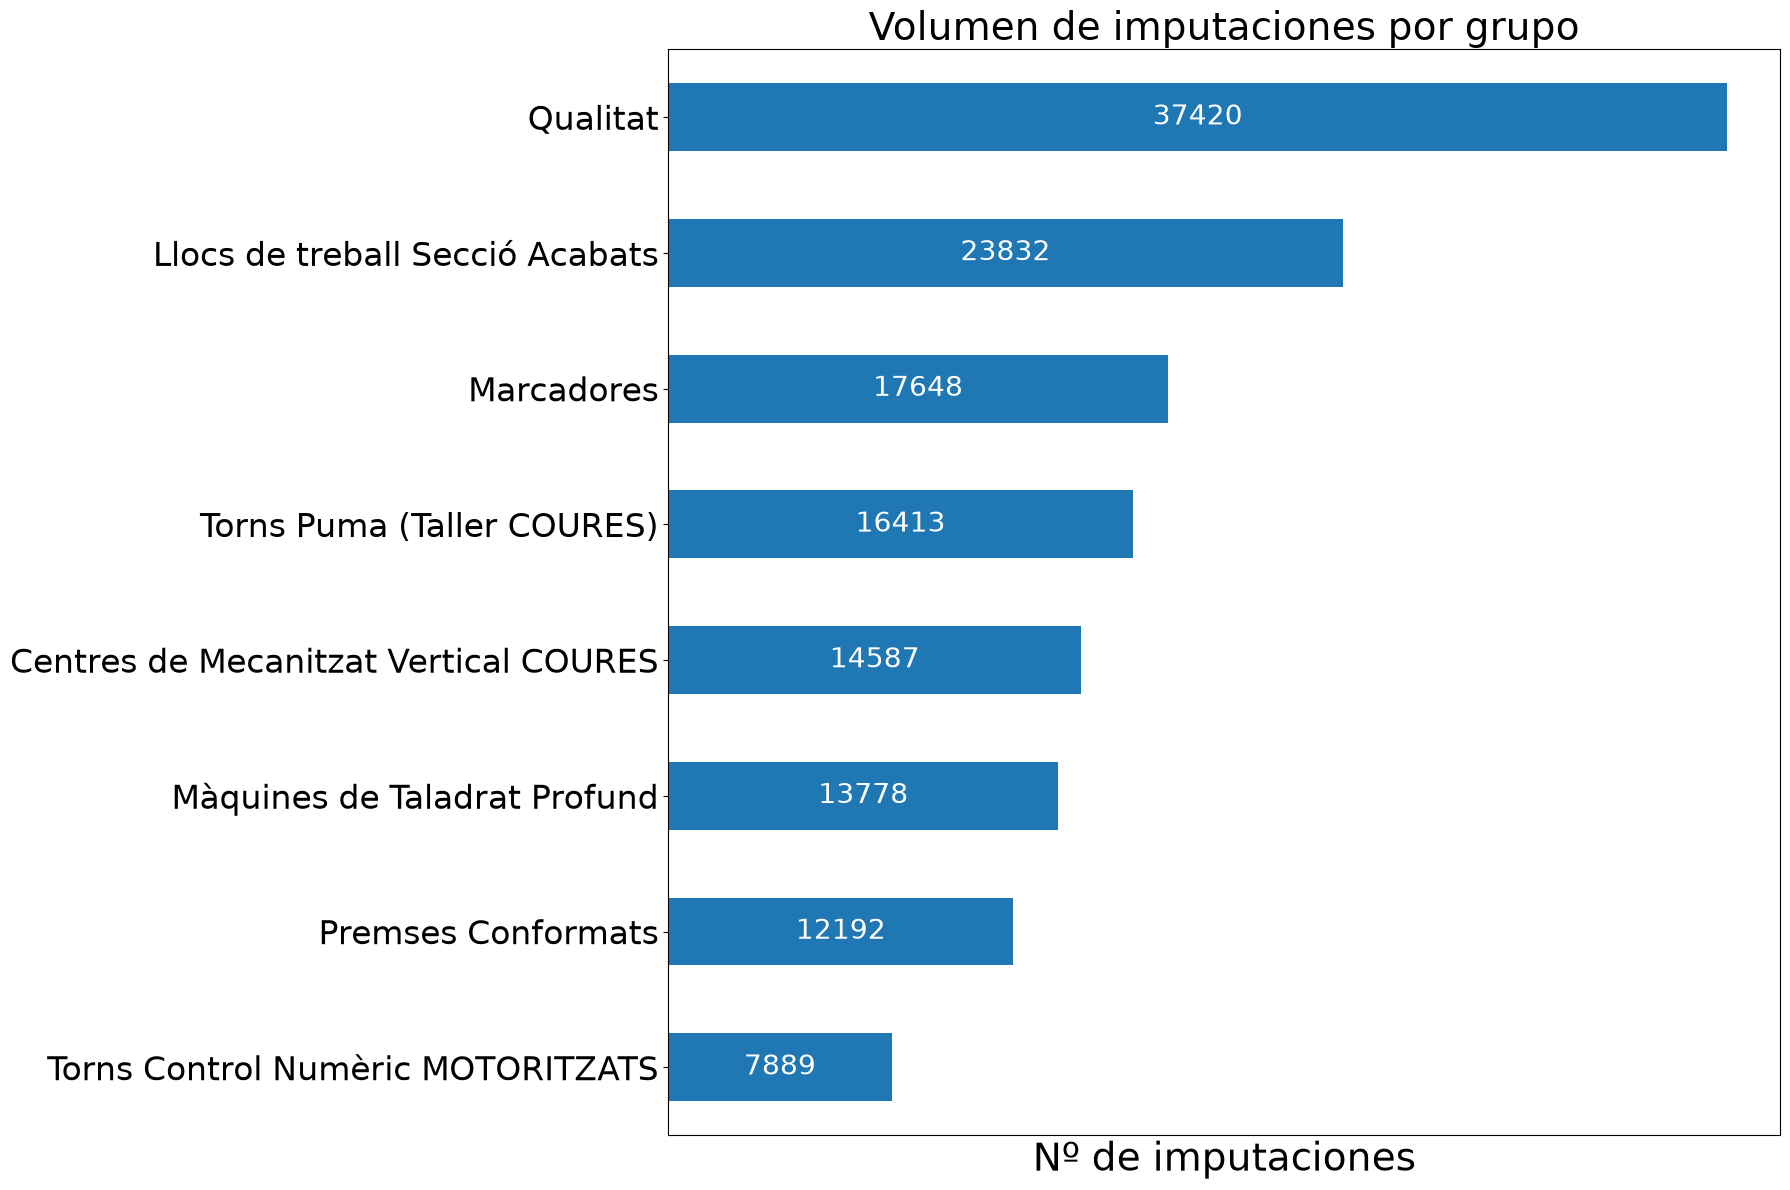

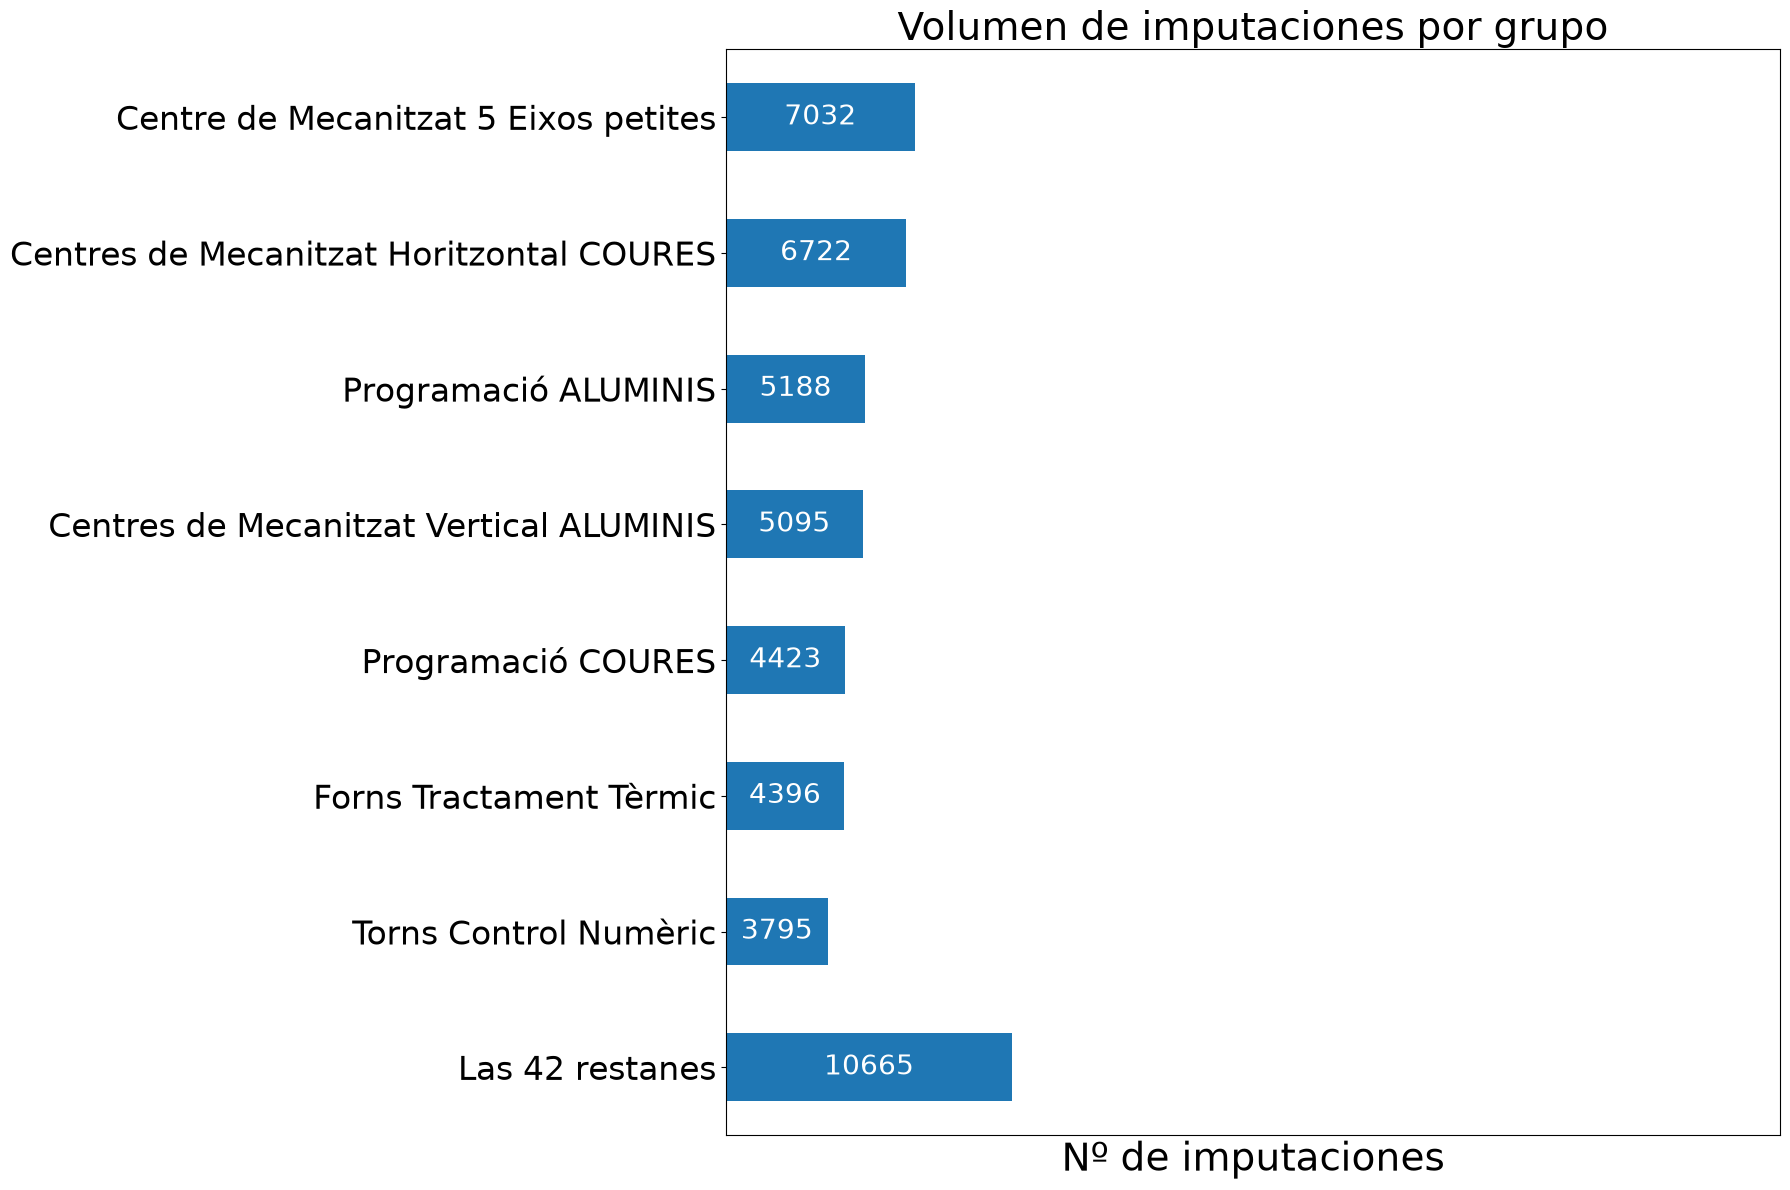

In [123]:
uso_grupo = (
    tabla_decision.groupby("Description_y")["num_imputaciones"]
    .sum()
    .sort_values(ascending=False)
)

TOP_ULTIMO = 7
tramos_fijos = [(0, 8)]              # solo el primer tramo es bloque fijo
inicio_ultimo = tramos_fijos[-1][1]  # = 8

# "El resto" antes, porque entra en el máximo global
resto = uso_grupo.iloc[inicio_ultimo + TOP_ULTIMO:].sum()

# Eje X común a ambos gráficos, incluida "El resto"
x_max = max(uso_grupo.iloc[:inicio_ultimo + TOP_ULTIMO].max(), resto) * 1.05

def dibujar(datos, titulo):
    ax = datos.plot(kind="barh", figsize=(18, 12), fontsize=24)
    ax.set_xlim(0, x_max)                                               # eje X común
    ax.bar_label(ax.containers[0], label_type="center", color="white", fontsize=20)  # valor dentro
    ax.set_ylabel("") 
    ax.set_xticks([])                                                  # sin "CodMachineGroup"
    plt.xlabel("Nº de imputaciones", fontsize=28)
    plt.title(titulo, fontsize=28)
    plt.tight_layout()
    plt.show()

# Tramo 1: top 8
for i, (ini, fin) in enumerate(tramos_fijos, start=1):
    datos = uso_grupo.iloc[ini:fin].sort_values()
    if datos.empty:
        continue
    dibujar(datos, f"Volumen de imputaciones por grupo")

# Tramo 2: top 7 de lo que queda + "El resto"
top_ultimo = uso_grupo.iloc[inicio_ultimo : inicio_ultimo + TOP_ULTIMO].sort_values()

datos = top_ultimo
if resto > 0:
    datos = pd.concat([pd.Series({"Las 42 restanes": resto}), top_ultimo])

if not datos.empty:
    dibujar(datos, "Volumen de imputaciones por grupo")

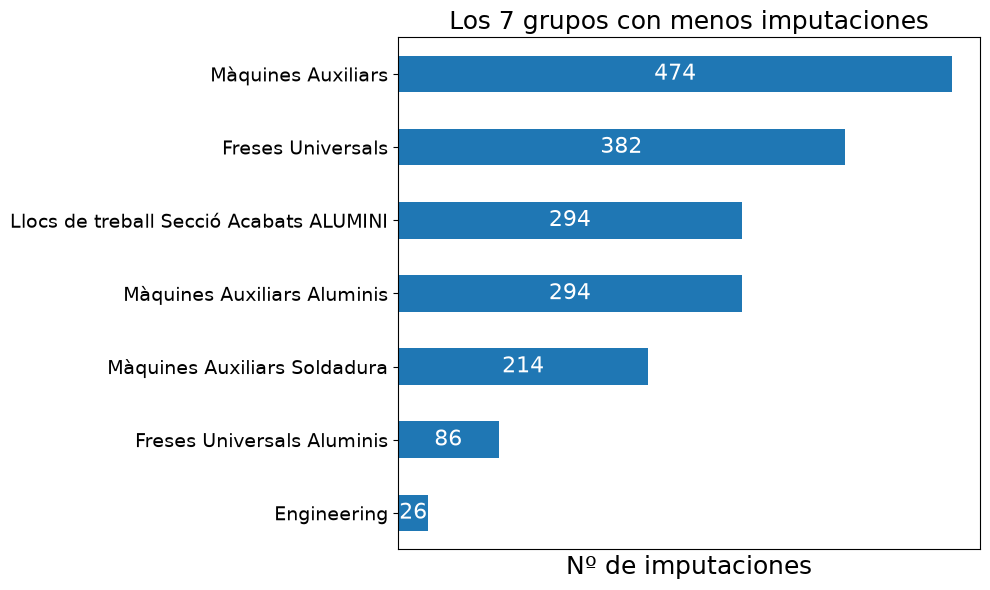

In [133]:
uso_grupo = (
    tabla_decision.groupby("Description_y")["num_imputaciones"]
    .sum()
    .sort_values(ascending=False)
)

# Los 8 con menos uso: la cola de la Serie
bottom8 = uso_grupo.tail(7).sort_values()   # ascendente para el barh

ax = bottom8.plot(kind="barh", figsize=(10, 6), fontsize=14)
ax.bar_label(ax.containers[0], label_type="center", color="white", fontsize=16)
ax.set_ylabel("")
ax.set_xticks([])    
plt.xlabel("Nº de imputaciones", fontsize=18)
plt.title("Los 7 grupos con menos imputaciones", fontsize=18)
plt.tight_layout()
plt.show()

## Correlación entre imputaciones y fases

In [135]:
display(imputations.sample(1))

,FechaCreacionDte,smNodoId,smNodoNme,smOrdenId,smMaterialId,smOrdenNme,smFaseId,smFaseNme,CantidadManualOKNbr,CantidadManualNOKNbr,MinutosRealNbr,MinutosPreparacionNbr,MinutosProduccionNbr,PorcentajeDedicacionNbr,ProductivoInd,smIncidenciaId,smIncidenciaNme,smFasePersonalizado1Txt,smNodoId2,smNodoPersonalizado1Nbr,smNodoPersonalizado2Nbr,ssEnumFaseEstadoId,SmFaseUid,TraspasadoInd,JsonBodyTxt,JsonResponseTxt
18473,2026-06-03 16:17:54.330,TP02,MTP IMSA MF800C-HD Màquina Taladres Profunds,OF2604582,PE2JA3X0068,COPPER PART Holder MD153969S,15,MTP,0.0,0.0,0.0,0.0,0.0,0.0,1,NaN,NaN,NaN,TP02,NaN,NaN,FINALIZADA_OLANET,FFE0BB57-A0EB-4A60-ABA7-5ED5DCA4F292,1,"{""CodCompany"":""100"",""CodSite"":""01"",""Imputation...","{""Result"":true,""errorDetails"":[],""newIDImputat..."


In [151]:
imputations100 = imputations[imputations["JsonBodyTxt"].str.contains("100")]
total_fases_imputaciones = len(imputations100["SmFaseUid"].unique()) 
print(f"Total fases con imputaciones:{total_fases_imputaciones}")
print(f"Porcentaje de fases con imputaciones: {(total_fases_imputaciones/len(FASE)*100)}")

Total fases con imputaciones:69319
Porcentaje de fases con imputaciones: 59.72943862823661
